# Star Wars Galaxy Map — Fusion PDF + xlsx

Les deux sources sont complémentaires :
- **`galaxy-pdf-manual-clean.xlsx`** — ~6 400 systèmes (nettoyage manuel de galaxy_base.csv)
- **`sw-galaxy.pdf`** — 3 258 systèmes (PDF officiel), dont 112 absents de l'xlsx

Ce notebook fusionne les deux, déduplique sur le nom du système, et exporte
`galaxy_clean.csv` + `galaxy_clean.json`.

## 1. Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                        'openpyxl', 'pdfplumber', '-q'])
print('ok')

ok


In [2]:
import re, json, math, string, warnings
from pathlib import Path

import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

XLSX_PATH = Path('galaxy-pdf-manual-clean.xlsx')
PDF_PATH  = Path('sw-galaxy.pdf')
OUT_CSV   = Path('galaxy_clean.csv')
OUT_JSON  = Path('galaxy_clean.json')

## 2. Chargement xlsx

In [3]:
df_xlsx = pd.read_excel(XLSX_PATH, dtype=str, keep_default_na=False, engine='openpyxl')
df_xlsx.columns = ['system', 'sector', 'region', 'grid']
df_xlsx = df_xlsx.apply(lambda c: c.str.strip())
df_xlsx['system'] = df_xlsx['system'].str.replace(r'\.0$', '', regex=True)
df_xlsx = df_xlsx[df_xlsx['system'].ne('') & df_xlsx['system'].ne('SYSTEM')].copy()
df_xlsx['source'] = 'xlsx'
print(f'xlsx : {len(df_xlsx):,} entrées')
df_xlsx.head(4)

xlsx : 6,403 entrées


,system,sector,region,grid,source
0,5251977,Quence,Outer Rim Territories,P-18,xlsx
1,23 Mere,,Colonies,M-13,xlsx
2,2GS-91E20,,Core Worlds,M-11,xlsx
3,A-Foroon,Arkanis,Outer Rim Territories,R-16,xlsx


## 3. Extraction PDF

In [4]:
HEADER = {'SYSTEM', 'SECTOR', 'REGION', 'GRID'}
pdf_rows = []

with pdfplumber.open(PDF_PATH) as pdf:
    for page in pdf.pages:
        for tbl in page.extract_tables():
            for row in tbl:
                if row and row[0] and row[0].strip() not in HEADER:
                    cleaned = [(c or '').strip() for c in row]
                    if len(cleaned) == 4:
                        pdf_rows.append(cleaned)

df_pdf = pd.DataFrame(pdf_rows, columns=['system', 'sector', 'region', 'grid'])
df_pdf['source'] = 'pdf'
print(f'PDF : {len(df_pdf):,} entrées')
df_pdf.head(4)

PDF : 3,258 entrées


,system,sector,region,grid,source
0,5251977,Quence,Outer Rim Territories,P-18,pdf
1,Adratharpe,,Mid Rim,H-15,pdf
2,2GS-91E20,,Core Worlds,M-11,pdf
3,Aduba,Bheriz,Outer Rim Territories,U-11,pdf


## 4. Comparaison & fusion

In [5]:
xlsx_names = set(df_xlsx['system'])
pdf_names  = set(df_pdf['system'])

only_pdf  = pdf_names  - xlsx_names
only_xlsx = xlsx_names - pdf_names
common    = xlsx_names & pdf_names

print(f'Commun aux deux sources : {len(common):,}')
print(f'Uniquement dans le PDF  : {len(only_pdf):,}  ← à ajouter')
print(f'Uniquement dans xlsx    : {len(only_xlsx):,}')
print()
print('Systèmes présents dans le PDF mais absents du xlsx (échantillon) :')
for s in sorted(only_pdf)[:20]:
    print(f'  {s}')

Commun aux deux sources : 3,146
Uniquement dans le PDF  : 112  ← à ajouter
Uniquement dans xlsx    : 3,256

Systèmes présents dans le PDF mais absents du xlsx (échantillon) :
  Anorelga
  Arath
  Arron Prime
  Atravis
  Bakisian Drift
  Barnahof
  Belkadan
  Bethars
  Bleuf
  Bothawui
  Bryndar
  Caloria
  Carruthia
  Ceti 597
  Cheravh
  Citlik
  Coriallis
  Crispin
  Dachat
  Danteel


In [6]:
# Entrées PDF manquantes dans xlsx → on les ajoute
df_missing = df_pdf[df_pdf['system'].isin(only_pdf)].copy()
print(f'Entrées PDF à ajouter : {len(df_missing)}')

# Fusion : xlsx (source principale) + manquants PDF
df_merged = pd.concat([df_xlsx, df_missing], ignore_index=True)

# Dédupliquer sur le nom (garder la première occurrence — xlsx prioritaire)
df_merged = df_merged.drop_duplicates(subset=['system'], keep='first').copy()
print(f'Total après fusion & dédup : {len(df_merged):,}')

Entrées PDF à ajouter : 112
Total après fusion & dédup : 6,514


## 5. Nettoyage final + identifiants

In [7]:
GRID_RE = re.compile(r'^([A-Z])-(\d+)$')

def split_grid(g):
    m = GRID_RE.match(str(g).strip())
    return (m.group(1), int(m.group(2))) if m else ('', None)

df_merged[['grid_col', 'grid_row']] = df_merged['grid'].apply(
    lambda g: pd.Series(split_grid(g))
)

# Trier alphabétiquement par système
df_merged = df_merged.sort_values('system', key=lambda s: s.str.lower()).reset_index(drop=True)
df_merged.insert(0, 'id', [f'sw-{i:05d}' for i in range(len(df_merged))])

df_final = df_merged.drop(columns=['source'])
print(f'Colonnes : {list(df_final.columns)}')
print(f'Total final : {len(df_final):,}')
df_final.head(5)

Colonnes : ['id', 'system', 'sector', 'region', 'grid', 'grid_col', 'grid_row']
Total final : 6,514


,id,system,sector,region,grid,grid_col,grid_row
0,sw-00000,23 Mere,,Colonies,M-13,M,13
1,sw-00001,2GS-91E20,,Core Worlds,M-11,M,11
2,sw-00002,5251977,Quence,Outer Rim Territories,P-18,P,18
3,sw-00003,A-Foroon,Arkanis,Outer Rim Territories,R-16,R,16
4,sw-00004,Aaeton,,Core Worlds,K-9,K,9


## 6. Validation

In [8]:
for c in ['system', 'sector', 'region', 'grid']:
    n   = (df_final[c] == '').sum()
    pct = 100 * n / len(df_final)
    print(f'  {c:10s} vides : {n:5d}  ({pct:.1f}%)')
print()
print('Régions :')
print(df_final['region'].replace('', 'Inconnue').value_counts())

  system     vides :     0  (0.0%)
  sector     vides :  1471  (22.6%)
  region     vides :     0  (0.0%)
  grid       vides :     0  (0.0%)

Régions :
region
Outer Rim Territories    2816
Mid Rim                  1195
Inner Rim                 574
Expansion Region          556
Core Worlds               478
Colonies                  403
Wild Space                233
Hutt Space                105
Unknown Regions           104
Deep Core                  48
Corporate Sector            1
Mid Rm                      1
Name: count, dtype: int64


## 7. Analyse exploratoire

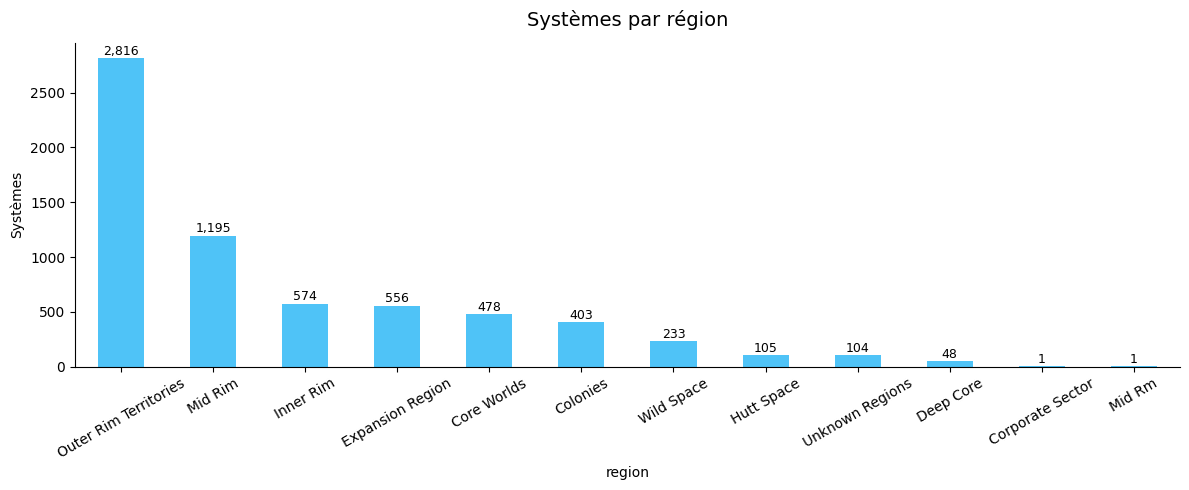

region
Outer Rim Territories    2816
Mid Rim                  1195
Inner Rim                 574
Expansion Region          556
Core Worlds               478
Colonies                  403
Wild Space                233
Hutt Space                105
Unknown Regions           104
Deep Core                  48
Corporate Sector            1
Mid Rm                      1


In [9]:
ALL_LETTERS   = list(string.ascii_uppercase)
region_counts = df_final['region'].replace('', 'Inconnue').value_counts()

fig, ax = plt.subplots()
region_counts.plot(kind='bar', ax=ax, color='#4fc3f7', edgecolor='none')
ax.set_title('Systèmes par région', fontsize=14, pad=12)
ax.set_ylabel('Systèmes')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 4),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(region_counts.to_string())

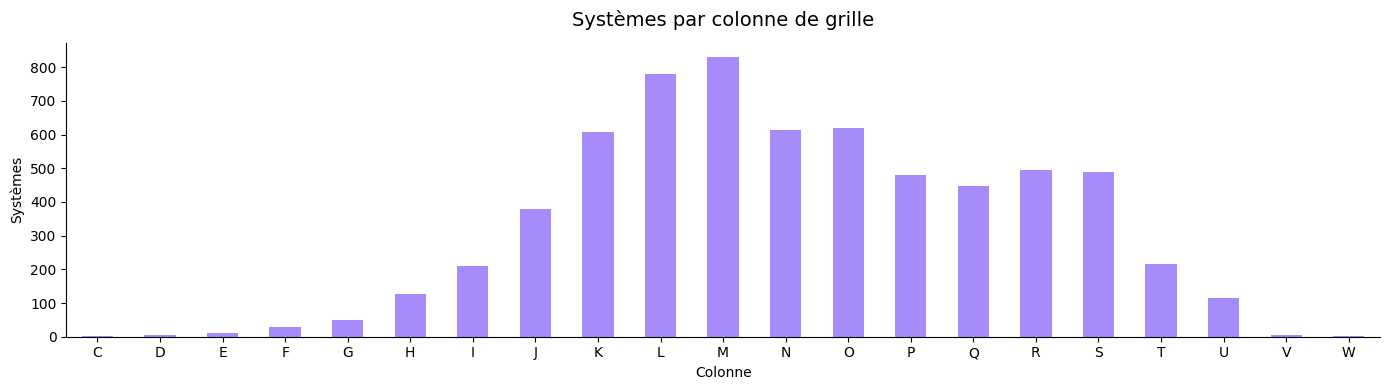

In [10]:
col_counts = df_final['grid_col'].replace('', 'N/A').value_counts()
col_counts = col_counts.reindex(
    [l for l in ALL_LETTERS if l in col_counts.index]
    + (['N/A'] if 'N/A' in col_counts.index else []), fill_value=0)
fig, ax = plt.subplots(figsize=(14, 4))
col_counts.plot(kind='bar', ax=ax, color='#a78bfa', edgecolor='none')
ax.set_title('Systèmes par colonne de grille', fontsize=14, pad=12)
ax.set_xlabel('Colonne'); ax.set_ylabel('Systèmes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

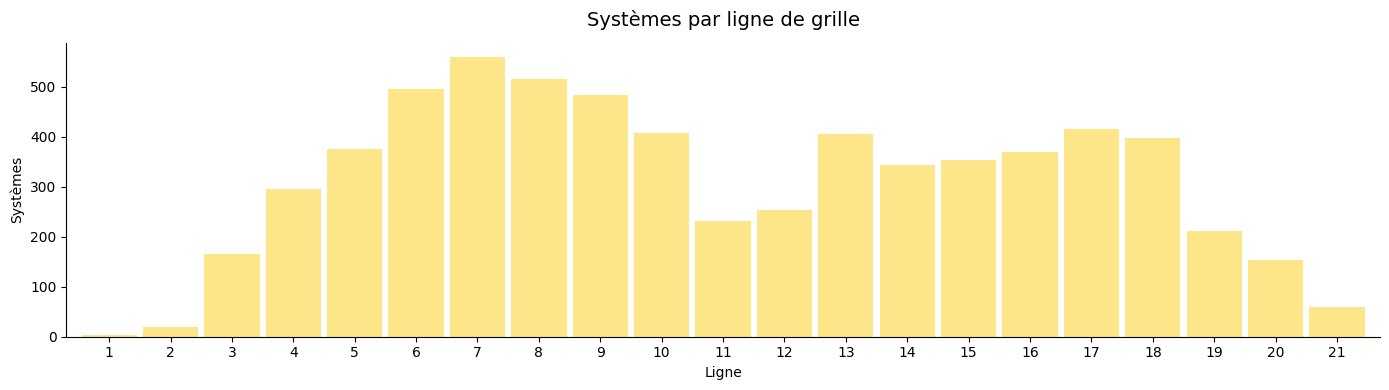

In [11]:
row_counts = df_final['grid_row'].dropna().astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 4))
row_counts.plot(kind='bar', ax=ax, color='#fde68a', edgecolor='none', width=0.9)
ax.set_title('Systèmes par ligne de grille', fontsize=14, pad=12)
ax.set_xlabel('Ligne'); ax.set_ylabel('Systèmes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

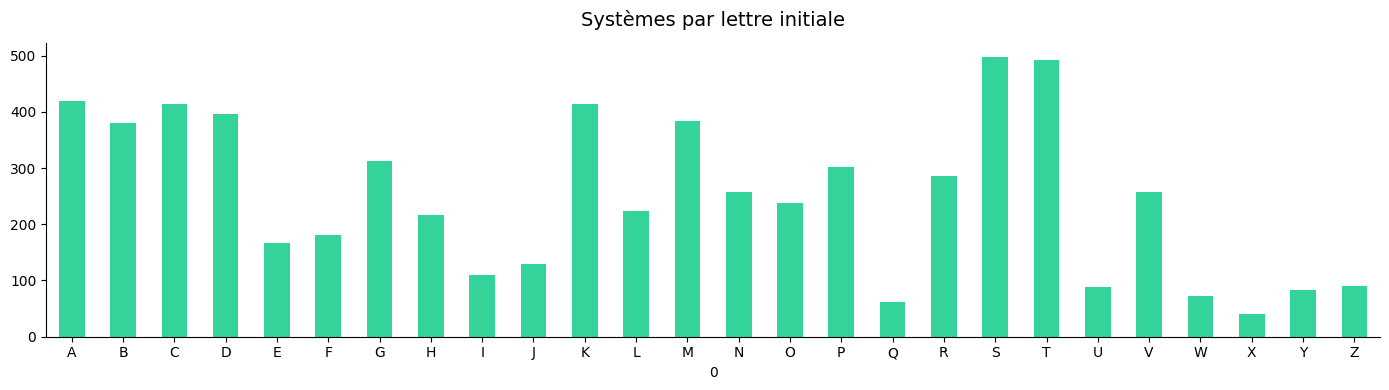

In [12]:
first_letter = (
    df_final['system'].str.upper()
    .str.extract(r'^([A-Z])')[0]
    .value_counts().reindex(ALL_LETTERS, fill_value=0)
)
fig, ax = plt.subplots(figsize=(14, 4))
first_letter.plot(kind='bar', ax=ax, color='#34d399', edgecolor='none')
ax.set_title('Systèmes par lettre initiale', fontsize=14, pad=12)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

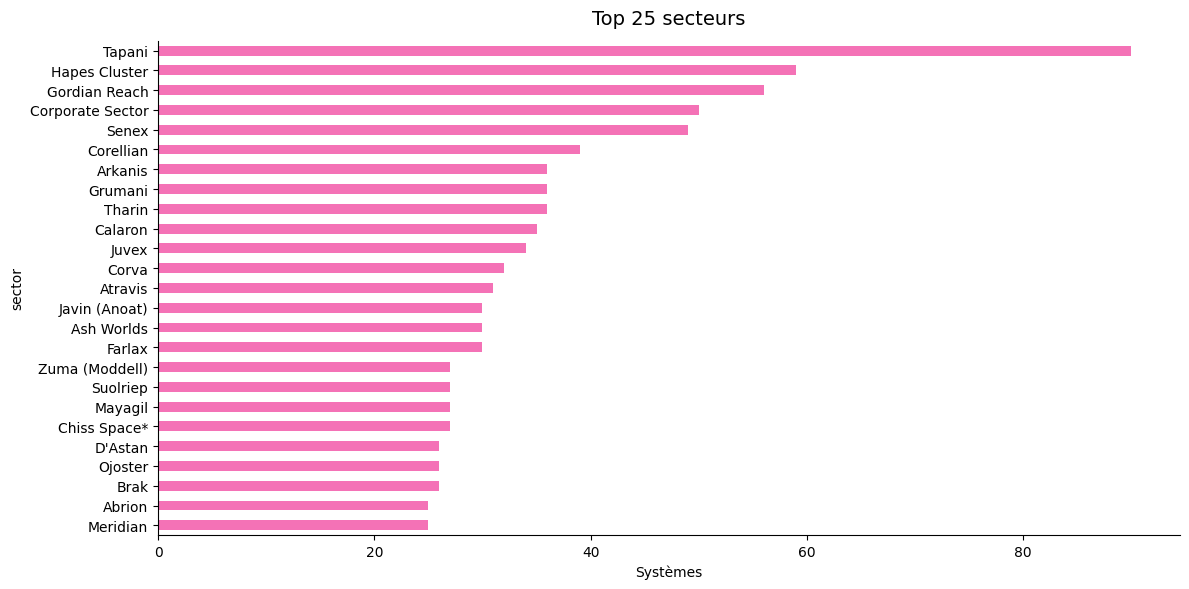

Secteurs uniques : 616


In [13]:
sector_counts = (
    df_final[df_final['sector'] != '']['sector']
    .value_counts().head(25)
)
fig, ax = plt.subplots(figsize=(12, 6))
sector_counts[::-1].plot(kind='barh', ax=ax, color='#f472b6', edgecolor='none')
ax.set_title('Top 25 secteurs', fontsize=14, pad=12)
ax.set_xlabel('Systèmes')
plt.tight_layout(); plt.show()
print(f'Secteurs uniques : {df_final["sector"].replace("", pd.NA).dropna().nunique():,}')

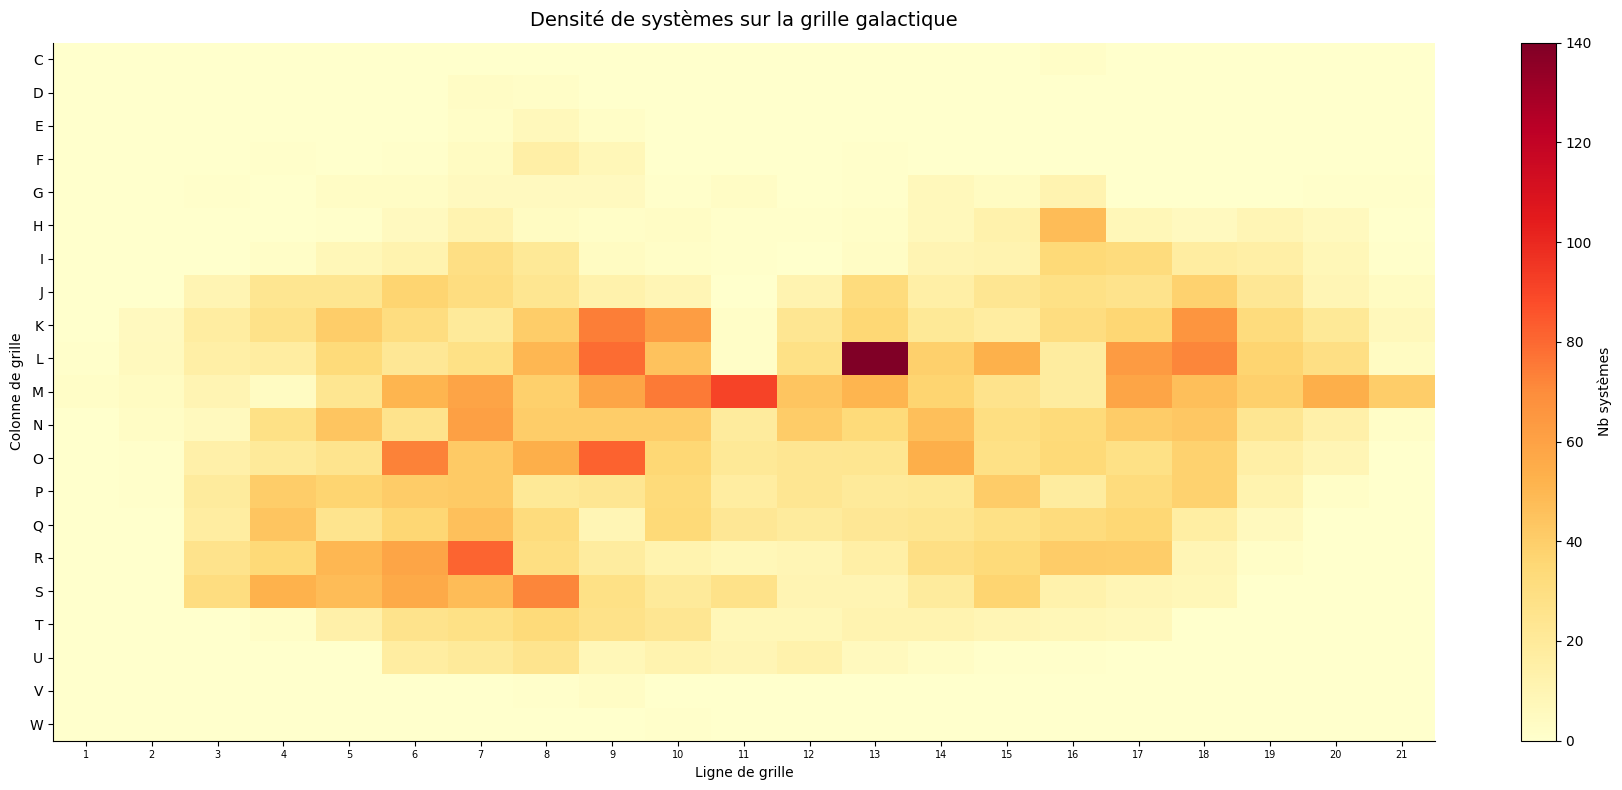

In [14]:
grid_df = df_final[df_final['grid_col'].ne('') & df_final['grid_row'].notna()].copy()
grid_df['grid_row'] = grid_df['grid_row'].astype(int)
col_order = sorted(grid_df['grid_col'].unique())
row_order = sorted(grid_df['grid_row'].unique())
pivot = (
    grid_df.groupby(['grid_col', 'grid_row']).size()
    .unstack(fill_value=0)
    .reindex(index=col_order, columns=row_order, fill_value=0)
)
fig, ax = plt.subplots(figsize=(18, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xticks(range(len(row_order))); ax.set_xticklabels(row_order, fontsize=7)
ax.set_yticks(range(len(col_order))); ax.set_yticklabels(col_order)
ax.set_xlabel('Ligne de grille'); ax.set_ylabel('Colonne de grille')
ax.set_title('Densité de systèmes sur la grille galactique', fontsize=14, pad=12)
plt.colorbar(im, ax=ax, label='Nb systèmes')
plt.tight_layout(); plt.show()

In [15]:
print('══ Résumé ══════════════════════════════════')
print(f'  Source xlsx              : {len(df_xlsx):,}')
print(f'  Source PDF               : {len(df_pdf):,}')
print(f'  Ajoutés depuis PDF       : {len(df_missing):,}')
print(f'  Total fusionné           : {len(df_final):,}')
print(f'  Avec secteur             : {(df_final["sector"] != "").sum():,}')
print(f'  Régions                  : {df_final["region"].replace("", pd.NA).dropna().nunique()}')
print(f'  Sans grille              : {(df_final["grid"] == "").sum()}')
print('════════════════════════════════════════════')

══ Résumé ══════════════════════════════════
  Source xlsx              : 6,403
  Source PDF               : 3,258
  Ajoutés depuis PDF       : 112
  Total fusionné           : 6,514
  Avec secteur             : 5,043
  Régions                  : 12
  Sans grille              : 0
════════════════════════════════════════════


## 8. Export

Champs JSON : `id`, `system`, `sector`, `region`, `grid`, `grid_col`, `grid_row`
+ `x` / `y` (calibration future sur `official_galaxy_map.jpeg`) + `works` (works du site).

In [16]:
df_final.to_csv(OUT_CSV, index=False)
print(f'CSV → {OUT_CSV}  ({len(df_final):,} lignes)')

CSV → galaxy_clean.csv  (6,514 lignes)


In [17]:
records = (
    df_final[['id','system','sector','region','grid','grid_col','grid_row']]
    .to_dict(orient='records')
)
for r in records:
    for k, v in list(r.items()):
        if v == '' or (isinstance(v, float) and math.isnan(v)):
            r[k] = None
        elif hasattr(v, 'item'):
            r[k] = v.item()
    r['x'] = None; r['y'] = None; r['works'] = []

with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)
print(f'JSON → {OUT_JSON}  ({len(records):,} entrées)')
print(json.dumps(records[:2], indent=2, ensure_ascii=False))

JSON → galaxy_clean.json  (6,514 entrées)
[
  {
    "id": "sw-00000",
    "system": "23 Mere",
    "sector": null,
    "region": "Colonies",
    "grid": "M-13",
    "grid_col": "M",
    "grid_row": 13,
    "x": null,
    "y": null,
    "works": []
  },
  {
    "id": "sw-00001",
    "system": "2GS-91E20",
    "sector": null,
    "region": "Core Worlds",
    "grid": "M-11",
    "grid_col": "M",
    "grid_row": 11,
    "x": null,
    "y": null,
    "works": []
  }
]
